<a href="https://colab.research.google.com/github/josesalamanca25/josesalamanca25.github.io/blob/main/Mision3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<ipython-input-28-83c267f1b25d>:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date of Incident'] = pd.to_datetime(df['Date of Incident'], errors='coerce')


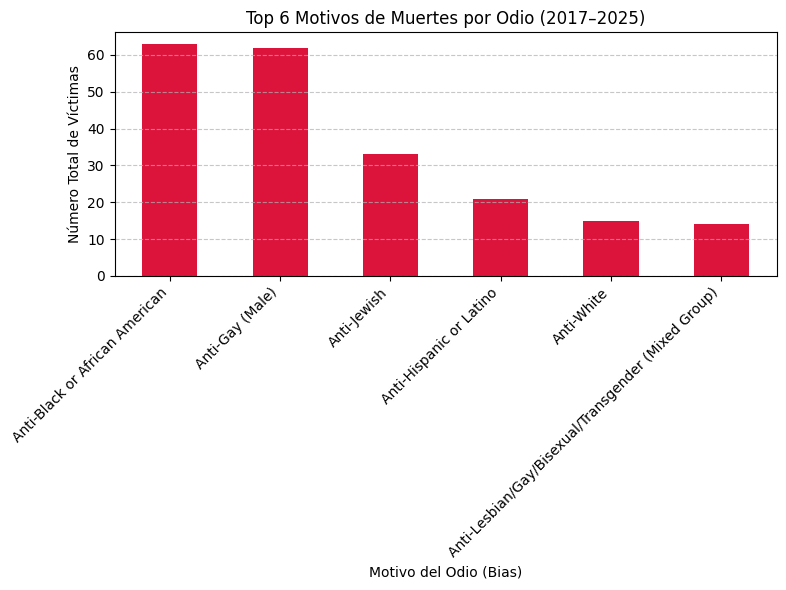

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar archivo
df = pd.read_csv('/content/Hate_Crimes_2017-2025.csv')

# Asegurar conversión correcta de fechas
df['Date of Incident'] = pd.to_datetime(df['Date of Incident'], errors='coerce')

# Crear columna "Deaths" basada en víctimas reportadas
df['Victims Under 18'] = pd.to_numeric(df['Number of Victims under 18'], errors='coerce').fillna(0)
df['Victims Over 18'] = pd.to_numeric(df['Number of Victims over 18'], errors='coerce').fillna(0)
df['Deaths'] = df['Victims Under 18'] + df['Victims Over 18']

# Agrupar por motivo de odio ("Bias") y sumar muertes
bias_deaths = df.groupby('Bias')['Deaths'].sum().sort_values(ascending=False)

# Filtrar los 6 principales motivos
top_6_bias = bias_deaths.head(6)

# Graficar
plt.figure(figsize=(8, 6))
top_6_bias.plot(kind='bar', color='crimson')
plt.title('Top 6 Motivos de Muertes por Odio (2017–2025)')
plt.xlabel('Motivo del Odio (Bias)')
plt.ylabel('Número Total de Víctimas')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



<ipython-input-32-b6042d21c7de>:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date of Incident'] = pd.to_datetime(df['Date of Incident'], errors='coerce')


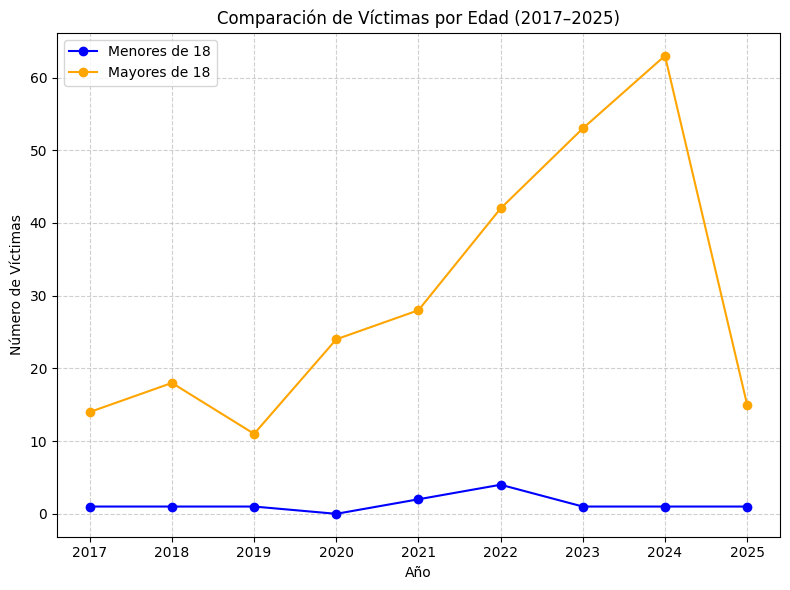

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar archivo CSV
df = pd.read_csv('/content/Hate_Crimes_2017-2025.csv')

# Convertir fechas correctamente
df['Date of Incident'] = pd.to_datetime(df['Date of Incident'], errors='coerce')

# Limpiar y convertir columnas de víctimas a numérico
df['Victims Under 18'] = pd.to_numeric(df['Number of Victims under 18'], errors='coerce').fillna(0)
df['Victims Over 18'] = pd.to_numeric(df['Number of Victims over 18'], errors='coerce').fillna(0)

# Extraer año desde la fecha
df['Year'] = df['Date of Incident'].dt.year

# Filtrar por años entre 2017 y 2025
df_filtered = df[df['Year'].between(2017, 2025)]

# Agrupar por año y sumar víctimas menores y mayores de 18
yearly_victims = df_filtered.groupby('Year')[['Victims Under 18', 'Victims Over 18']].sum()

# Graficar comparación por año
plt.figure(figsize=(8,6))
plt.plot(yearly_victims.index, yearly_victims['Victims Under 18'], marker='o', label='Menores de 18', color='blue')
plt.plot(yearly_victims.index, yearly_victims['Victims Over 18'], marker='o', label='Mayores de 18', color='orange')

plt.title('Comparación de Víctimas por Edad (2017–2025)')
plt.xlabel('Año')
plt.ylabel('Número de Víctimas')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

<ipython-input-44-5d37c448f4dc>:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date of Incident'] = pd.to_datetime(df['Date of Incident'], errors='coerce')


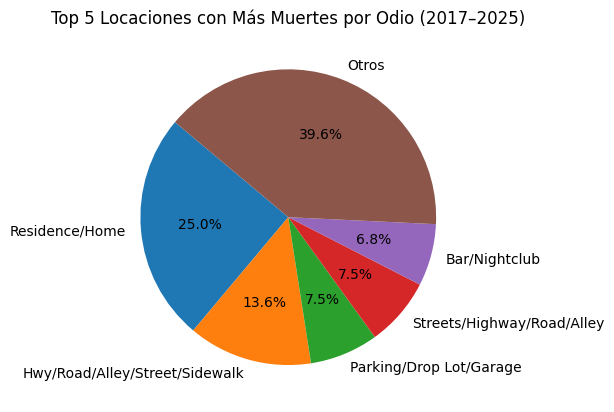

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar archivo CSV
df = pd.read_csv('/content/Hate_Crimes_2017-2025.csv')

# Convertir fechas correctamente
df['Date of Incident'] = pd.to_datetime(df['Date of Incident'], errors='coerce')

# Limpiar y convertir columnas de víctimas a numérico
df['Victims Under 18'] = pd.to_numeric(df['Number of Victims under 18'], errors='coerce').fillna(0)
df['Victims Over 18'] = pd.to_numeric(df['Number of Victims over 18'], errors='coerce').fillna(0)

# Extraer año desde la fecha
df['Year'] = df['Date of Incident'].dt.year

# Filtrar por años entre 2017 y 2025
df_filtered = df[df['Year'].between(2017, 2025)]

# -------------------- GRÁFICO DE LÍNEAS -------------------- #
# Agrupar por año y sumar víctimas menores y mayores de 18
yearly_victims = df_filtered.groupby('Year')[['Victims Under 18', 'Victims Over 18']].sum()

# -------------------- GRÁFICO CIRCULAR POR LOCACIÓN -------------------- #
# Crear columna total de víctimas
df_filtered['Total Victims'] = df_filtered['Victims Under 18'] + df_filtered['Victims Over 18']

# Agrupar por locación y sumar total de víctimas
location_totals = df_filtered.groupby('Offense Location')['Total Victims'].sum().sort_values(ascending=False)

# Seleccionar top 5 locaciones
top_5_locations = location_totals.head()

# Agrupar el resto como "Otros"
others_sum = location_totals.iloc[5:].sum()
top_5_locations['Otros'] = others_sum

# Graficar
plt.figure(figsize=(6, 6))
top_5_locations.plot(kind='pie', autopct='%1.1f%%', startangle=140)
plt.title('Top 5 Locaciones con Más Muertes por Odio (2017–2025)')
plt.ylabel('')
plt.tight_layout()
plt.show()
